In [1]:
using ITensors
using ITensorMPS
using JLD2
using Plots
using LaTeXStrings
using Printf
using Polynomials
using Statistics
using GLM
using DataFrames





In [2]:

data_dir = joinpath(@__DIR__, "data")

# all_data[truncation][sigma] = loaded_data_dict 
all_data = Dict{Float64, Dict{Float64, Any}}() 

sigma_value = 0.0

trunc_values = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]

for trunc in trunc_values
    all_data[trunc] = Dict{Float64, Any}()
    
    # Format the truncation exactly as the saving script did
    trunc_str = @sprintf("%.1e", trunc)
    file_name = "data_clean_fid_$(trunc_str).jld2" 
    file_path = joinpath(data_dir, file_name) 
    
    if isfile(file_path) 
        try
            data = load(file_path)
            all_data[trunc][sigma_value] = data 
            println("Successfully loaded: Trunc=$trunc_str, σ=$sigma_value")
        catch e
            println("ERROR loading file: $file_name -> $e")
        end
    else
        println("File not found: $file_name") 
    end
end

Successfully loaded: Trunc=1.0e-16, σ=0.0
Successfully loaded: Trunc=8.0e-16, σ=0.0
Successfully loaded: Trunc=1.0e-15, σ=0.0
Successfully loaded: Trunc=2.0e-15, σ=0.0
Successfully loaded: Trunc=4.0e-15, σ=0.0
Successfully loaded: Trunc=6.0e-15, σ=0.0
Successfully loaded: Trunc=1.0e-14, σ=0.0
Successfully loaded: Trunc=2.0e-14, σ=0.0
Successfully loaded: Trunc=4.0e-14, σ=0.0
Successfully loaded: Trunc=6.0e-14, σ=0.0
Successfully loaded: Trunc=8.0e-14, σ=0.0
Successfully loaded: Trunc=1.0e-13, σ=0.0
Successfully loaded: Trunc=1.0e-12, σ=0.0
Successfully loaded: Trunc=1.0e-11, σ=0.0
Successfully loaded: Trunc=1.0e-10, σ=0.0
Successfully loaded: Trunc=1.0e-09, σ=0.0
Successfully loaded: Trunc=1.0e-08, σ=0.0


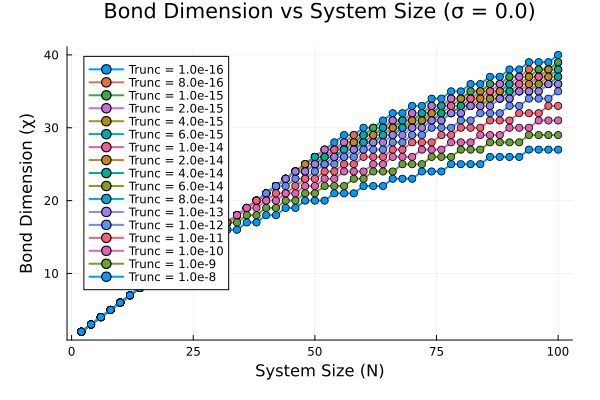

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\bd_clean_truncations.png"

In [3]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0

p_bd = plot(
    title = "Bond Dimension vs System Size (σ = $target_sigma)",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft, 
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # Accommodates both the new clean script output and the old array structure
        bond_dims_full = haskey(data, "bond_dims") ? data["bond_dims"] : data["avg_arr"]
        
        mask = bond_dims_full .> 0
        N_vals = N_full[mask]
        bond_dims_vals = bond_dims_full[mask]
        
        plot!(p_bd, N_vals, bond_dims_vals, 
            label = "Trunc = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_bd)
savefig(p_bd, joinpath("images", "bd_clean_truncations.png"))

# Spectra

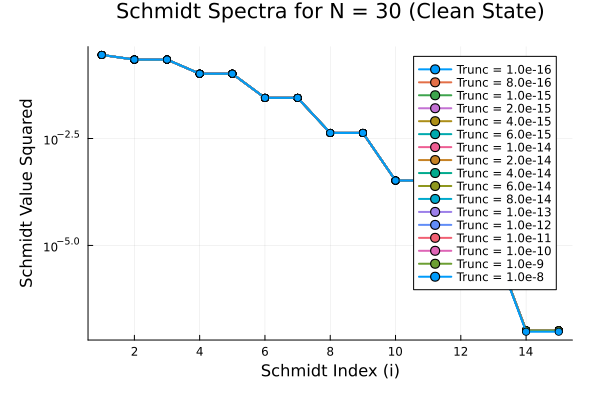

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\spectra_clean_truncations_N=30.png"

In [4]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0
target_N = 30

p_spectra = plot(
    title = "Schmidt Spectra for N = $target_N (Clean State)",
    xlabel = "Schmidt Index (i)",
    ylabel = "Schmidt Value Squared",
    legend = :topright,
    yscale = :log10,
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        idx = findfirst(==(target_N), N_full)
        
        if !isnothing(idx)
            # Accommodates both the new clean script output and the old array structure
            spectra_full = haskey(data, "spectra") ? data["spectra"] : data["spectra_avg"]
            spectra_vals = spectra_full[idx, :]
            
            valid_spectra = filter(x -> x > 0, spectra_vals)
            sorted_spectra = sort(valid_spectra, rev=true)
            
            plot!(p_spectra, 1:length(sorted_spectra), sorted_spectra, 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                linewidth = 2)
        else
            println("Warning: N = $target_N not found for Trunc = $trunc")
        end
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_spectra)
savefig(p_spectra, joinpath("images", "spectra_clean_truncations_N=$target_N.png"))

# Fidelity


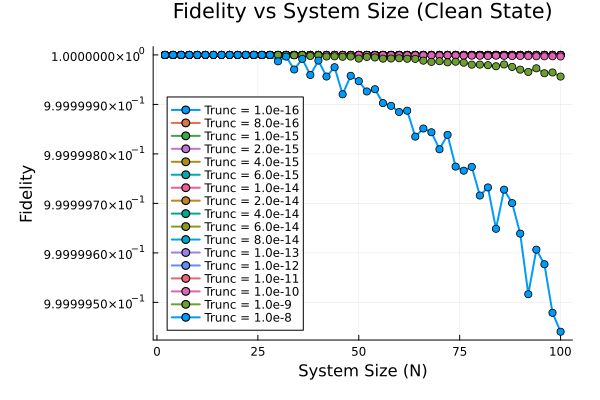

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\fid_clean_truncations.png"

In [5]:
p_fid = plot(
    title = "Fidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = "Fidelity",
    legend = :bottomleft, 
    margin = 5Plots.mm,
    grid = true
)

for trunc in target_truncs
    if haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma)
        data = all_data[trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # Accommodates both the new clean script output and the old array structure
        fid_full = haskey(data, "fidelities") ? data["fidelities"] : data["fid_avg"]
        
        mask = fid_full .> 0
        N_vals = N_full[mask]
        fid_vals = fid_full[mask]
        
        plot!(p_fid, N_vals, fid_vals, 
            label = "Trunc = $(trunc)", 
            marker = :circle, 
            linewidth = 2)
    else
        println("Warning: Data not found for Trunc = $trunc, σ = $target_sigma")
    end
end

display(p_fid)
savefig(p_fid, joinpath("images", "fid_clean_truncations.png"))

# Infidelity


In [6]:
"""
    get_infidelity_data(all_data, target_trunc, target_sigma)

Extracts system size (N), infidelity (beta), and error bars (if applicable) for a specific 
truncation and sigma from the loaded data dictionary.
"""
function get_infidelity_data(all_data, target_trunc, target_sigma)
    if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
        data = all_data[target_trunc][target_sigma]
        
        N_full = data["N_range"]
        
        # 1. Handle Key Changes for Bond Dimensions (used for masking)
        bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
        mask = data[bd_key] .> 0 
        
        N_vals = N_full[mask]
        
        # 2. Handle Key Changes for Fidelity
        fid_key = haskey(data, "fidelities") ? "fidelities" : "fid_avg"
        xi_vals = data[fid_key][mask] 
        
        # Calculate infidelity (beta)
        beta_vals = sqrt.(max.(0.0, 1.0 .- xi_vals.^2))
        
        # 3. Handle Errors (Only present in noisy/averaged data)
        if haskey(data, "fid_err")
            xi_errs = data["fid_err"][mask] 
            beta_errs = Float64[]
            for (x, b, dx) in zip(xi_vals, beta_vals, xi_errs)
                if b > 1e-10
                    push!(beta_errs, (x / b) * dx)
                else
                    push!(beta_errs, 0.0) 
                end
            end
            return N_vals, beta_vals, beta_errs
        else
            # Clean states have no standard deviation/error
            return N_vals, beta_vals, nothing 
        end
    else
        @warn "Data not found for Trunc = $target_trunc, σ = $target_sigma"
        return nothing
    end
end

get_infidelity_data

# Infidelity with changing truncs

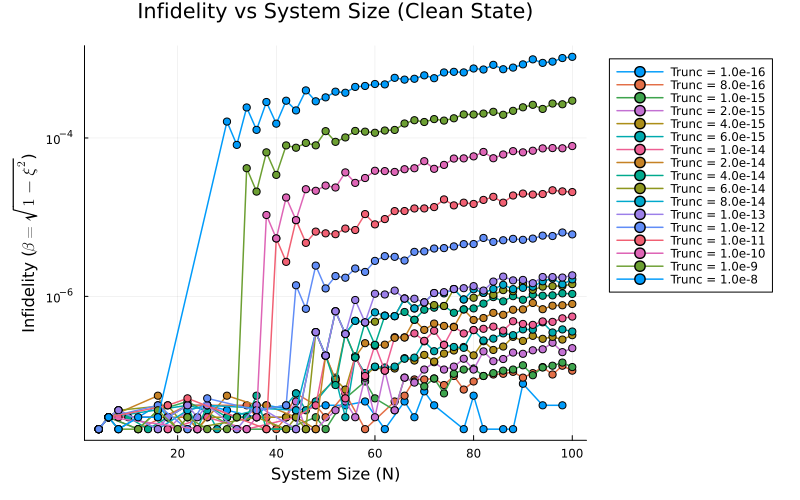

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_clean_truncations.png"

In [7]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0

p_infid = plot(
    title = "Infidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :outertopright, 
    yscale = :log10, 
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for trunc in target_truncs
    result = get_infidelity_data(all_data, trunc, target_sigma)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        
        valid_mask = beta_vals .> 0.0
        
        if any(valid_mask)
            plot!(p_infid, N_vals[valid_mask], beta_vals[valid_mask], 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5)
        else
            println("Note: Infidelity is exactly 0.0 for all N at Trunc = $trunc")
        end
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infid_clean_truncations.png"))

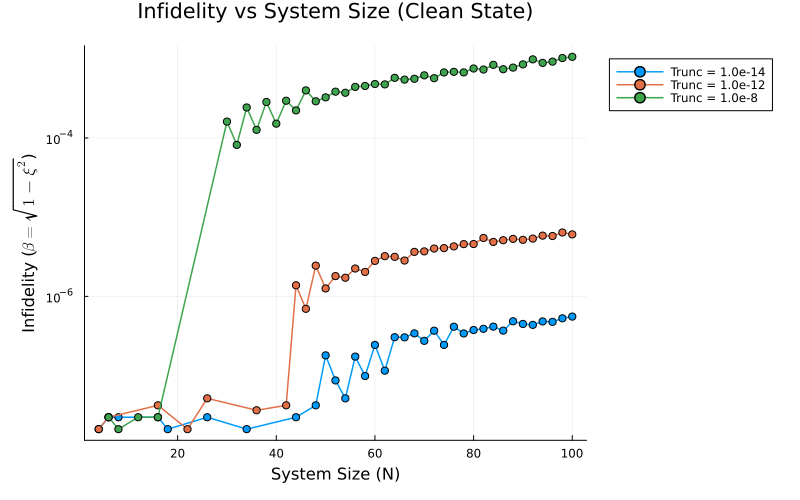

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_clean_truncations.png"

In [8]:
target_truncs = [1e-14, 1e-12, 1e-8]
target_sigma = 0.0

p_infid = plot(
    title = "Infidelity vs System Size (Clean State)",
    xlabel = "System Size (N)",
    ylabel = L"Infidelity ($\beta = \sqrt{1 - \xi^2}$)",
    legend = :outertopright, 
    yscale = :log10, 
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for trunc in target_truncs
    result = get_infidelity_data(all_data, trunc, target_sigma)
    if !isnothing(result)
        N_vals, beta_vals, beta_errs = result
        
        valid_mask = beta_vals .> 0.0
        
        
        if any(valid_mask)
            plot!(p_infid, N_vals[valid_mask], beta_vals[valid_mask], 
                label = "Trunc = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5)
        else
            println("Note: Infidelity is exactly 0.0 for all N at Trunc = $trunc")
        end
    end
end

display(p_infid)
savefig(p_infid, joinpath("images", "infid_clean_truncations.png"))

In [9]:
using JLD2
using Statistics

function interpolate_missing_data(y_vals)
    # y_new = copy(y_vals)
    y_new = y_vals
    n = length(y_vals)
    
    for i in 1:n

        if y_vals[i] <= 0.0
            valid_neighbours = Float64[]
            
            
            for j in (i-2):(i+2)
                if j != i && j >= 1 && j <= n && y_vals[j] > 0.0
                    push!(valid_neighbours, y_vals[j])
                end
            end
            
            if !isempty(valid_neighbours)
                y_new[i] = mean(valid_neighbours)
            end
        end
    end
    return y_new
end



interpolate_missing_data (generic function with 1 method)

In [10]:
target_truncs = [1e-14, 1e-12, 1e-8]
target_sigma = 0.0

for trunc in target_truncs
    # Get infidelity data for this truncation
    result = get_infidelity_data(all_data, trunc, target_sigma)
    
    if !isnothing(result)
        # Extract N values, infidelities, and errors from result
        N_vals, beta_vals, beta_errs = result
        
        # Interpolate the infidelity values to fill in any zeros or very small values
        beta_vals_interpolated = interpolate_missing_data(beta_vals)
        
        # Create output filename and path
        path = joinpath(@__DIR__, "data")
        original_filename = string("data_clean_fid_", trunc, ".jld2")
        new_filename = replace(original_filename, ".jld2" => "_avg.jld2")
        new_filepath = joinpath(path, new_filename)
        
        # Save the interpolated data with all components
        save(new_filepath, "N_vals", N_vals, "beta_vals", beta_vals_interpolated, "beta_errs", beta_errs)
        println(string("Saved interpolated infidelity data to ", new_filepath))
    else
        println("Warning: No data found for trunc = $trunc, σ = $target_sigma")
    end
end


Saved interpolated infidelity data to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-14_avg.jld2
Saved interpolated infidelity data to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-12_avg.jld2
Saved interpolated infidelity data to c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-8_avg.jld2


In [11]:
using JLD2

# Load the interpolated infidelity data
averaged_data = Dict()
target_truncs = [1e-14, 1e-12, 1e-8]
path = joinpath(@__DIR__, "data")

for trunc in target_truncs
    original_filename = string("data_clean_fid_", trunc, ".jld2")
    new_filename = replace(original_filename, ".jld2" => "_avg.jld2")
    new_filepath = joinpath(path, new_filename)
    
    if isfile(new_filepath)
        averaged_data[trunc] = load(new_filepath)
        println(string("Successfully loaded ", new_filepath))
    else
        println(string("File not found: ", new_filepath))
    end
end


Successfully loaded c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-14_avg.jld2
Successfully loaded c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-12_avg.jld2
Successfully loaded c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Fidelity\data\data_clean_fid_1.0e-8_avg.jld2


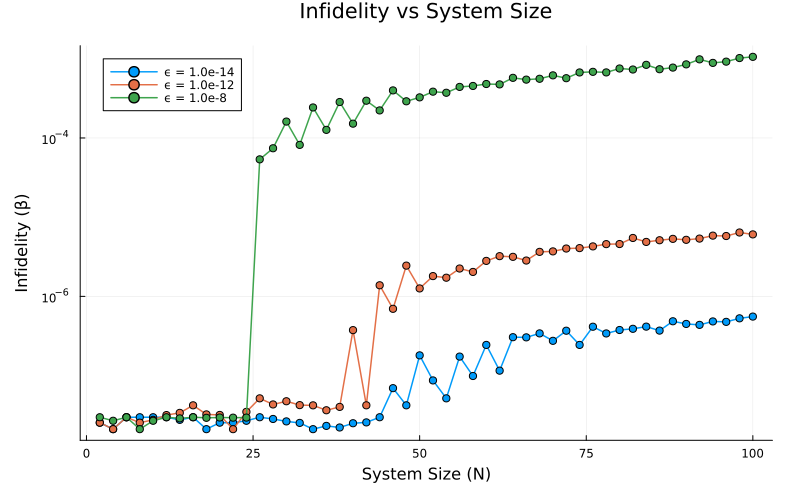

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images_report\\infid_vs_system_size_clean.png"

In [12]:
target_truncs = [1e-14, 1e-12, 1e-8]

p_infid_avg = plot(
    title = "Infidelity vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Infidelity (β)",
    legend = :topleft, 
    yscale = :log10, 
    grid = true,
    size = (800, 500),
    margin = 5Plots.mm
)

for trunc in target_truncs
    if haskey(averaged_data, trunc)
        data = averaged_data[trunc]
        
        N_vals = data["N_vals"]
        beta_vals = data["beta_vals"]
        
        valid_mask = beta_vals .> 0.0
        
        if any(valid_mask)
            plot!(p_infid_avg, N_vals[valid_mask], beta_vals[valid_mask], 
                label = "ϵ = $(trunc)", 
                marker = :circle, 
                markersize = 4,
                linewidth = 1.5)
        else
            println("Note: Infidelity is exactly 0.0 for all N at Trunc = $trunc")
        end
    else
        println("Warning: Data not found for Trunc = $trunc")
    end
end

display(p_infid_avg)
savefig(p_infid_avg, joinpath("images_report", "infid_vs_system_size_clean.png"))


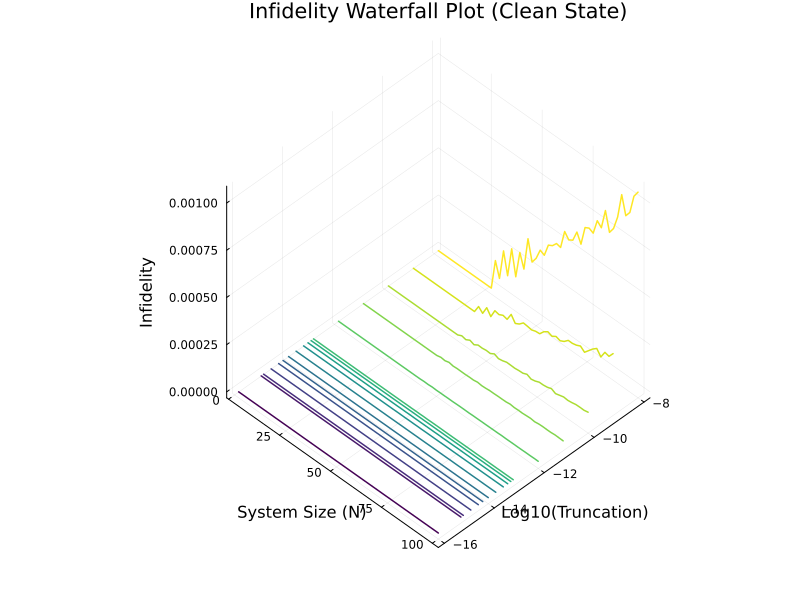

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\infid_waterfall_clean.png"

In [13]:
target_truncs = [1e-16, 8e-16, 1e-15, 2e-15, 4e-15, 6e-15, 1e-14, 2e-14, 4e-14, 6e-14, 8e-14, 1e-13, 1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
target_sigma = 0.0

# Find which truncations actually exist in the loaded data for the clean state
valid_truncs = filter(trunc -> haskey(all_data, trunc) && haskey(all_data[trunc], target_sigma), target_truncs)
available_truncs = sort(valid_truncs)

if isempty(available_truncs)
    println("None of the chosen truncations were found for σ = $target_sigma.")
else
    p_waterfall_infid = plot(
        xlabel = "System Size (N)",
        ylabel = "Log10(Truncation)",
        zlabel = "Infidelity",
        title = "Infidelity Waterfall Plot (Clean State)",
        camera = (45, 45),
        legend = false,
        size = (800, 600)
    )
    
    line_colors = palette(:viridis, length(available_truncs))
    
    plot_count = 0
    
    for (idx, trunc) in enumerate(available_truncs)
        result = get_infidelity_data(all_data, trunc, target_sigma)
        
        if !isnothing(result)
            N_vals, beta_vals, _ = result
            
            if !isempty(N_vals)
                # Use log10 so the lines are evenly spaced visually
                Y_vals = fill(log10(trunc), length(N_vals))
                
                plot!(p_waterfall_infid, N_vals, Y_vals, beta_vals,
                      linecolor = line_colors[idx], linewidth = 1.5)
                
                plot_count += 1
            end
        end
    end
    
    if plot_count > 0
        display(p_waterfall_infid)
        savefig(p_waterfall_infid, joinpath("images", "infid_waterfall_clean.png"))
    else
        println("No valid infidelity data found to plot.")
    end
end

# Clean case scaling

In [14]:
"""
    f_eps(epsilon)

Calculates the scaling factor f(ϵ) from the truncation threshold.
"""
function f_eps(epsilon::Float64)
    return sqrt(0.5 * log(1.0 / epsilon))
end

"""
    predict_chi(N, epsilon)

Calculates the predicted bond dimension χ by taking the minimum of the 
exact linear scaling and the truncated square-root scaling.
"""
function predict_chi(N::Float64, epsilon::Float64)
    chi_exact = (N / 2.0) + 1.0
    chi_trunc = f_eps(epsilon) * sqrt(N)
    return min(chi_exact, chi_trunc)
end

"""
    strong_error_bound(N, epsilon)

Calculates the theoretical strong upper bound for the discarded weight 
(fidelity loss) based on the Gaussian tail approximation.
"""
function strong_error_bound(N::Float64, epsilon::Float64)
    return (sqrt(N) / (4.0 * f_eps(epsilon))) * epsilon
end

strong_error_bound

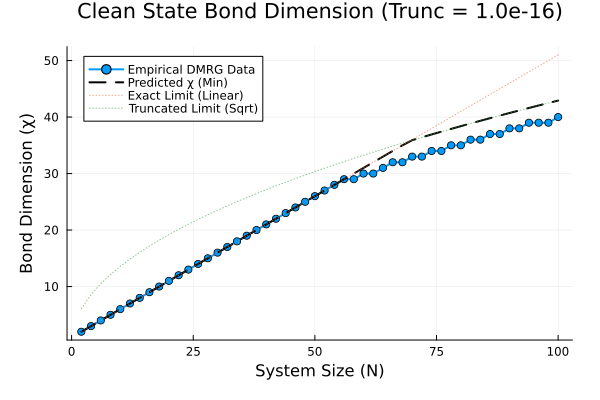

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Fidelity\\images\\clean_chi_scaling_verification.png"

In [15]:
target_trunc = 1e-16
target_sigma = 0.0

if haskey(all_data, target_trunc) && haskey(all_data[target_trunc], target_sigma)
    data = all_data[target_trunc][target_sigma]
    
    bd_key = haskey(data, "bond_dims") ? "bond_dims" : "avg_arr"
    mask = data[bd_key] .> 0 
    
    N_vals = data["N_range"][mask]
    empirical_chi = data[bd_key][mask]
    
    # Calculate predictions
    predicted_chi = [predict_chi(Float64(N), target_trunc) for N in N_vals]
    chi_exact_vals = [(N / 2.0) + 1.0 for N in N_vals]
    chi_trunc_vals = [f_eps(target_trunc) * sqrt(N) for N in N_vals]
    
    p_scale = plot(
        title = "Clean State Bond Dimension (Trunc = $target_trunc)",
        xlabel = "System Size (N)",
        ylabel = "Bond Dimension (χ)",
        legend = :topleft,
        margin = 5Plots.mm,
        grid = true
    )
    
    # Plot empirical data
    plot!(p_scale, N_vals, empirical_chi, 
          label="Empirical DMRG Data", marker=:circle, linewidth=2, color=1)
          
    # Plot predicted min function
    plot!(p_scale, N_vals, predicted_chi, 
          label="Predicted χ (Min)", linestyle=:dash, linewidth=2, color=:black)
          
    # Plot individual bounds for visualization
    plot!(p_scale, N_vals, chi_exact_vals, 
          label="Exact Limit (Linear)", linestyle=:dot, alpha=0.6, color=2)
    plot!(p_scale, N_vals, chi_trunc_vals, 
          label="Truncated Limit (Sqrt)", linestyle=:dot, alpha=0.6, color=3)
          
    display(p_scale)
    savefig(p_scale, joinpath("images", "clean_chi_scaling_verification.png"))
else
    println("Data not found for Trunc = $target_trunc")
end